In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/README.md
/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv


In [2]:
import os
import time
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
DATA_PATH = "/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (15420, 29)


In [4]:
# ============================================
# CELL 4 - SELECT MODEL FEATURES
# ============================================

FEATURES = [
    "training_duration",
    "training_intensity",
    "training_load",
    "heart_rate",
    "sleep_quality",
    "recovery_score",
    "stress_level"
]

TARGET = "fatigue_index"

# Identifiers - NOT used as model inputs
IDENTIFIERS = [
    "athlete_id",
    "session_id"
]

print("Features used for training:")

for feature in FEATURES:
    print("-", feature)

print("\nIdentifiers (NOT used as model inputs):")

for identifier in IDENTIFIERS:
    print("-", identifier)

print("\nTarget:")
print("-", TARGET)

Features used for training:
- training_duration
- training_intensity
- training_load
- heart_rate
- sleep_quality
- recovery_score
- stress_level

Identifiers (NOT used as model inputs):
- athlete_id
- session_id

Target:
- fatigue_index


In [5]:
# ============================================
# CELL 5 - VERIFY REQUIRED COLUMNS
# ============================================

required_columns = FEATURES + IDENTIFIERS + [TARGET]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if len(missing_columns) == 0:
    print("All required columns are present!")
else:
    print("Missing columns:")

    for column in missing_columns:
        print("-", column)

All required columns are present!


In [6]:
# ============================================
# CELL 6 - CREATE MODEL DATASET
# ============================================

model_df = df[FEATURES + [TARGET]].copy()

print("Model dataset shape:", model_df.shape)

display(model_df.head())

Model dataset shape: (15420, 8)


,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level,fatigue_index
0,79.106564,5.678475,548.417962,NaN,5.466370,77.899691,0.375825,45.028687
1,116.954654,NaN,538.043815,40.000000,6.899090,74.845323,0.279165,42.254717
2,96.354742,6.643242,647.784339,76.174609,9.574152,83.538316,0.334061,61.870056
3,97.619130,6.194427,336.553431,100.543724,7.614297,79.966618,0.218766,50.268845
4,83.155527,5.835804,496.076352,78.001235,5.631979,56.945979,0.484086,29.233575


In [7]:
for col in FEATURES + [TARGET]:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("Numeric conversion completed.")

Numeric conversion completed.


In [8]:
print("Missing values:\n")
print(model_df.isnull().sum())

Missing values:

training_duration       0
training_intensity    632
training_load           0
heart_rate            354
sleep_quality         493
recovery_score          0
stress_level            0
fatigue_index           0
dtype: int64


In [9]:
before = len(model_df)

model_df = model_df.dropna(subset=[TARGET])

after = len(model_df)

print("Rows before removing missing target:", before)
print("Rows after removing missing target:", after)
print("Rows removed:", before - after)

Rows before removing missing target: 15420
Rows after removing missing target: 15420
Rows removed: 0


In [10]:
X = model_df[FEATURES].copy()
fatigue_index = model_df[TARGET].copy()

print("X shape:", X.shape)
print("Target shape:", fatigue_index.shape)

print("\nX columns:")
print(list(X.columns))

X shape: (15420, 7)
Target shape: (15420,)

X columns:
['training_duration', 'training_intensity', 'training_load', 'heart_rate', 'sleep_quality', 'recovery_score', 'stress_level']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_fatigue, y_test_fatigue = train_test_split(
    X,
    fatigue_index,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 12336
Testing samples : 3084


In [12]:
q1 = y_train_fatigue.quantile(1/3)
q2 = y_train_fatigue.quantile(2/3)

print("Low / Moderate boundary :", q1)
print("Moderate / High boundary:", q2)

Low / Moderate boundary : 47.26018698422907
Moderate / High boundary: 68.8946614564474


In [13]:
def fatigue_to_class(value):
    if value <= q1:
        return 0       # Low
    elif value <= q2:
        return 1       # Moderate
    else:
        return 2       # High


y_train = y_train_fatigue.apply(fatigue_to_class)
y_test = y_test_fatigue.apply(fatigue_to_class)

class_names = ["Low", "Moderate", "High"]

print("Class mapping:")
print("0 =", class_names[0])
print("1 =", class_names[1])
print("2 =", class_names[2])

Class mapping:
0 = Low
1 = Moderate
2 = High


In [14]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
fatigue_index
0    4112
1    4112
2    4112
Name: count, dtype: int64

Testing class distribution:
fatigue_index
0    1074
1    1053
2     957
Name: count, dtype: int64


In [15]:
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values after imputation:")
print("Training:", X_train.isnull().sum().sum())
print("Testing :", X_test.isnull().sum().sum())

Missing values after imputation:
Training: 0
Testing : 0


In [16]:
from sklearn.ensemble import RandomForestClassifier

EPOCHS = 50
TREES_PER_EPOCH = 10
BATCH_SIZE = 32

rf_model = RandomForestClassifier(
    n_estimators=TREES_PER_EPOCH,
    warm_start=True,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Random Forest configured!")
print("Epochs:", EPOCHS)
print("Trees added per epoch:", TREES_PER_EPOCH)
print("Final number of trees:", EPOCHS * TREES_PER_EPOCH)
print("Batch size display:", BATCH_SIZE)

Random Forest configured!
Epochs: 50
Trees added per epoch: 10
Final number of trees: 500
Batch size display: 32


In [17]:
import time
from sklearn.metrics import accuracy_score, log_loss

history = []

training_start = time.perf_counter()

print("Starting training...")
print("Epochs:", EPOCHS)
print("Training samples:", len(X_train))
print("Batch size:", BATCH_SIZE)
print("Model: Random Forest")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.perf_counter()

    # Add more trees
    current_trees = epoch * TREES_PER_EPOCH
    rf_model.set_params(n_estimators=current_trees)

    # Train / update the Random Forest
    rf_model.fit(X_train, y_train)

    # Training predictions
    train_probabilities = rf_model.predict_proba(X_train)
    train_predictions = rf_model.predict(X_train)

    # Monitoring loss
    loss = log_loss(
        y_train,
        train_probabilities,
        labels=[0, 1, 2]
    )

    accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    epoch_time = time.perf_counter() - epoch_start

    history.append({
        "epoch": epoch,
        "trees": current_trees,
        "loss": loss,
        "training_accuracy": accuracy,
        "epoch_time_seconds": epoch_time
    })

    total_batches = int(np.ceil(len(X_train) / BATCH_SIZE))

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Batch [{total_batches}/{total_batches}] "
        f"Loss: {loss:.4f}"
    )

    print("-" * 60)
    print(f"Epoch {epoch} completed")
    print(f"Average loss: {loss:.4f}")
    print(f"Training accuracy: {accuracy:.4f}")
    print(f"Time: {epoch_time:.2f} seconds")
    print(f"Trees in forest: {current_trees}")
    print("-" * 60)

total_training_time = time.perf_counter() - training_start

print("\nTraining completed!")
print(f"Total training time: {total_training_time:.2f} seconds")
print(f"Total training time: {total_training_time / 60:.2f} minutes")

Starting training...
Epochs: 50
Training samples: 12336
Batch size: 32
Model: Random Forest
Epoch [1/50] Batch [386/386] Loss: 0.1907
------------------------------------------------------------
Epoch 1 completed
Average loss: 0.1907
Training accuracy: 0.9852
Time: 0.23 seconds
Trees in forest: 10
------------------------------------------------------------
Epoch [2/50] Batch [386/386] Loss: 0.1853
------------------------------------------------------------
Epoch 2 completed
Average loss: 0.1853
Training accuracy: 0.9968
Time: 0.23 seconds
Trees in forest: 20
------------------------------------------------------------
Epoch [3/50] Batch [386/386] Loss: 0.1829
------------------------------------------------------------
Epoch 3 completed
Average loss: 0.1829
Training accuracy: 0.9985
Time: 0.25 seconds
Trees in forest: 30
------------------------------------------------------------
Epoch [4/50] Batch [386/386] Loss: 0.1822
------------------------------------------------------------
E

In [18]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    "/kaggle/working/random_forest_training_history.csv",
    index=False
)

print("Training history saved!")
display(history_df.head())

Training history saved!


,epoch,trees,loss,training_accuracy,epoch_time_seconds
0,1,10,0.190682,0.985246,0.229958
1,2,20,0.185292,0.996757,0.229049
2,3,30,0.182876,0.998460,0.248046
3,4,40,0.182157,0.999433,0.247389
4,5,50,0.181337,0.999919,0.260541


In [19]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)

print("Test prediction completed!")
print("Predictions:", len(y_pred))

Test prediction completed!
Predictions: 3084


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

try:
    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    roc_auc = np.nan

print("========== RANDOM FOREST EVALUATION ==========")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC         : {roc_auc:.4f}")

========== RANDOM FOREST EVALUATION ==========
Accuracy        : 0.6560
Precision       : 0.6570
Recall          : 0.6582
F1 Score        : 0.6576
ROC-AUC         : 0.8372


In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       0.72      0.72      0.72      1074
    Moderate       0.52      0.51      0.52      1053
        High       0.74      0.74      0.74       957

    accuracy                           0.66      3084
   macro avg       0.66      0.66      0.66      3084
weighted avg       0.65      0.66      0.66      3084



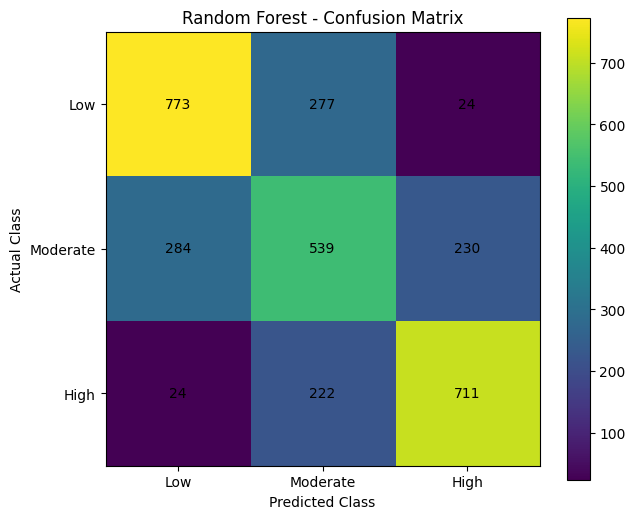

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [23]:
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_df.to_csv(
    "/kaggle/working/random_forest_evaluation_metrics.csv",
    index=False
)

display(evaluation_df)

,Metric,Score
0,Accuracy,0.655966
1,Precision,0.657045
2,Recall,0.658186
3,F1 Score,0.657600
4,ROC-AUC,0.837228


In [24]:
wall_time_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Epochs": [EPOCHS],
    "Trees_Per_Epoch": [TREES_PER_EPOCH],
    "Final_Trees": [EPOCHS * TREES_PER_EPOCH],
    "Training_Samples": [len(X_train)],
    "Testing_Samples": [len(X_test)],
    "Batch_Size_Display": [BATCH_SIZE],
    "Wall_Time_Seconds": [total_training_time],
    "Wall_Time_Minutes": [total_training_time / 60]
})

wall_time_df.to_csv(
    "/kaggle/working/random_forest_wall_time.csv",
    index=False
)

display(wall_time_df)

,Model,Epochs,Trees_Per_Epoch,Final_Trees,Training_Samples,Testing_Samples,Batch_Size_Display,Wall_Time_Seconds,Wall_Time_Minutes
0,Random Forest,50,10,500,12336,3084,32,28.119389,0.468656


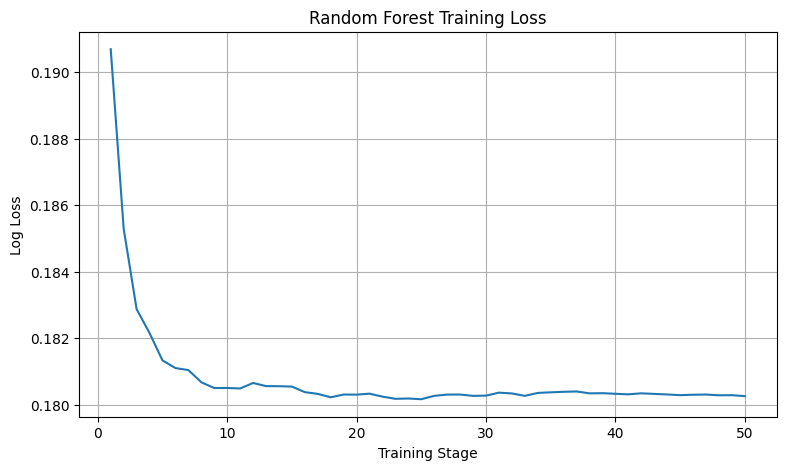

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["loss"]
)

plt.xlabel("Training Stage")
plt.ylabel("Log Loss")
plt.title("Random Forest Training Loss")

plt.grid(True)
plt.show()

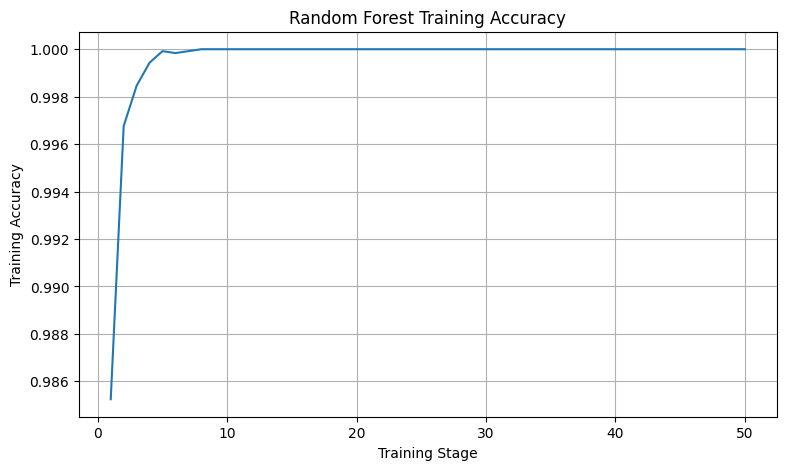

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["training_accuracy"]
)

plt.xlabel("Training Stage")
plt.ylabel("Training Accuracy")
plt.title("Random Forest Training Accuracy")

plt.grid(True)
plt.show()

In [27]:
feature_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
2,training_load,0.321372
1,training_intensity,0.157231
0,training_duration,0.122885
5,recovery_score,0.118830
4,sleep_quality,0.096360
6,stress_level,0.095017
3,heart_rate,0.088306


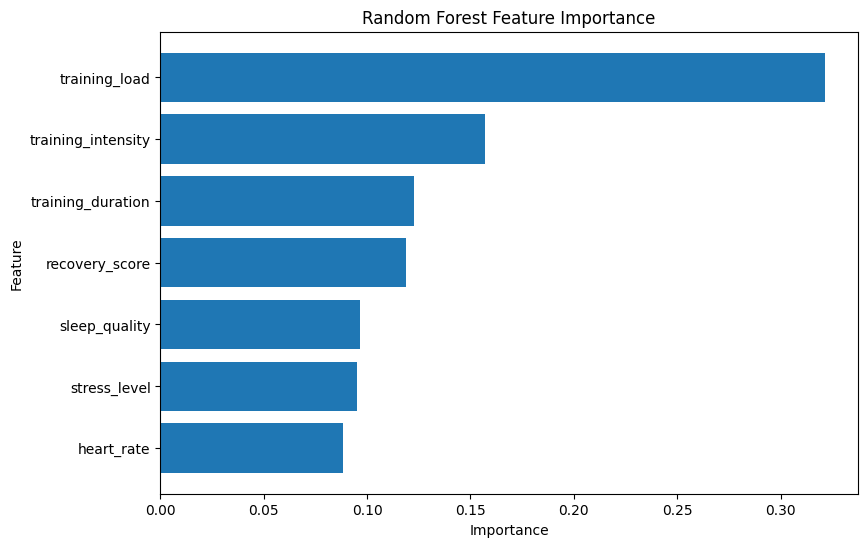

In [28]:
plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [29]:
importance_df.to_csv(
    "/kaggle/working/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance CSV saved.")

Feature importance CSV saved.


In [30]:
from sklearn.inspection import permutation_importance

print("Calculating permutation importance...")

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_Importance": perm_result.importances_mean,
    "Std_Importance": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    "Mean_Importance",
    ascending=False
)

display(permutation_df)

Calculating permutation importance...


,Feature,Mean_Importance,Std_Importance
2,training_load,0.304590,0.007383
5,recovery_score,0.020548,0.004359
6,stress_level,0.010692,0.003977
0,training_duration,0.009177,0.002472
1,training_intensity,0.008262,0.004569
3,heart_rate,0.000019,0.003567
4,sleep_quality,-0.001850,0.004862


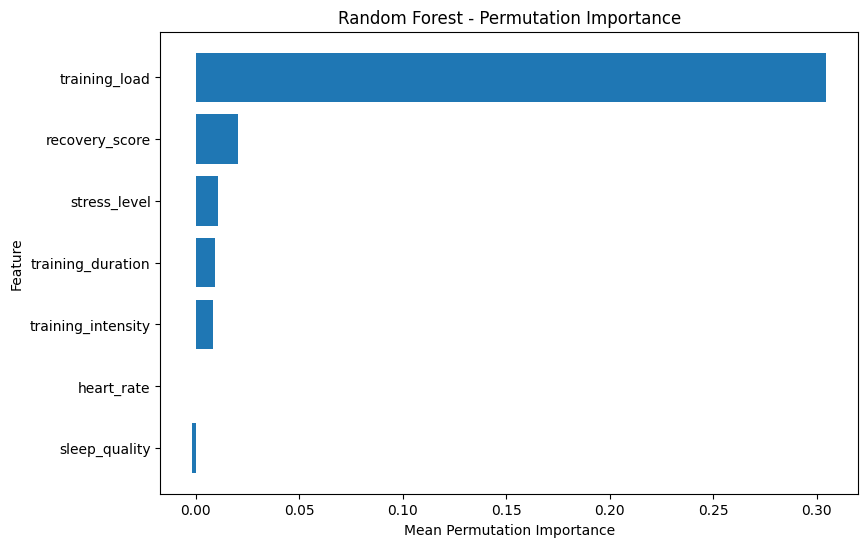

In [31]:
plt.figure(figsize=(9, 6))

plt.barh(
    permutation_df["Feature"],
    permutation_df["Mean_Importance"]
)

plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Permutation Importance")

plt.gca().invert_yaxis()

plt.show()

In [32]:
permutation_df.to_csv(
    "/kaggle/working/random_forest_permutation_importance.csv",
    index=False
)

print("Permutation importance CSV saved.")

Permutation importance CSV saved.


In [33]:
!pip install -q shap

In [34]:
import shap

print("Creating SHAP explainer...")

explainer = shap.TreeExplainer(rf_model)

X_shap = X_test.iloc[:500]

shap_result = explainer(X_shap)

print("SHAP explanation generated!")

Creating SHAP explainer...
SHAP explanation generated!


In [35]:
shap_values = shap_result.values

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (500, 7, 3)


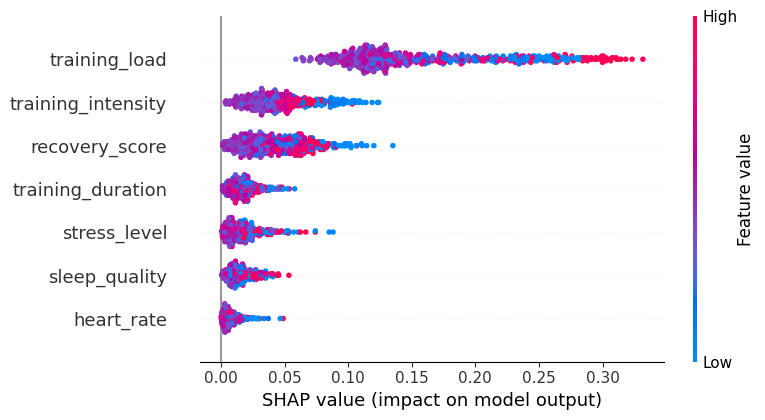

In [36]:
if shap_values.ndim == 3:
    shap_for_plot = np.mean(
        np.abs(shap_values),
        axis=2
    )
else:
    shap_for_plot = shap_values

shap.summary_plot(
    shap_for_plot,
    X_shap,
    feature_names=FEATURES
)

In [37]:
shap_importance = np.mean(
    np.abs(shap_for_plot),
    axis=0
)

shap_df = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_SHAP_Importance": shap_importance
})

shap_df = shap_df.sort_values(
    "Mean_SHAP_Importance",
    ascending=False
)

display(shap_df)

,Feature,Mean_SHAP_Importance
2,training_load,0.164670
1,training_intensity,0.045991
5,recovery_score,0.043030
0,training_duration,0.017222
6,stress_level,0.017187
4,sleep_quality,0.015602
3,heart_rate,0.007801


In [38]:
shap_df.to_csv(
    "/kaggle/working/random_forest_shap_importance.csv",
    index=False
)

print("SHAP importance CSV saved.")

SHAP importance CSV saved.


In [39]:
sample_index = 0

sample = X_test.iloc[[sample_index]]

prediction = rf_model.predict(sample)[0]
probabilities = rf_model.predict_proba(sample)[0]

print("========== INDIVIDUAL PREDICTION ==========")

print("Actual fatigue class:",
      class_names[y_test.iloc[sample_index]])

print("Predicted fatigue class:",
      class_names[prediction])

print("\nPrediction probabilities:")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: "
        f"{probabilities[i] * 100:.2f}%"
    )

print("\nInput factors:")

for feature in FEATURES:
    print(
        f"{feature}: "
        f"{sample.iloc[0][feature]}"
    )

========== INDIVIDUAL PREDICTION ==========
Actual fatigue class: Low
Predicted fatigue class: Moderate

Prediction probabilities:
Low: 28.60%
Moderate: 68.40%
High: 3.00%

Input factors:
training_duration: 64.63982198922983
training_intensity: 6.693077548723485
training_load: 545.8982747435949
heart_rate: 70.93557290430842
sleep_quality: 8.025855362910509
recovery_score: 76.84629528502566
stress_level: 0.3293105872099868


In [40]:
import joblib

MODEL_PATH = "/kaggle/working/random_forest_model.joblib"

joblib.dump(
    rf_model,
    MODEL_PATH
)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/kaggle/working/random_forest_model.joblib


In [41]:
import json

model_config = {
    "model": "Random Forest",
    "features": FEATURES,
    "target": TARGET,
    "classes": {
        "0": "Low",
        "1": "Moderate",
        "2": "High"
    },
    "low_moderate_boundary": float(q1),
    "moderate_high_boundary": float(q2),
    "epochs": EPOCHS,
    "trees_per_epoch": TREES_PER_EPOCH,
    "final_trees": EPOCHS * TREES_PER_EPOCH
}

with open(
    "/kaggle/working/random_forest_config.json",
    "w"
) as f:
    json.dump(model_config, f, indent=4)

print("Configuration saved!")

Configuration saved!


In [42]:
import os

print("========== GENERATED FILES ==========\n")

for file in os.listdir("/kaggle/working"):
    print(file)

========== GENERATED FILES ==========

random_forest_feature_importance.csv
random_forest_model.joblib
random_forest_permutation_importance.csv
random_forest_evaluation_metrics.csv
random_forest_shap_importance.csv
random_forest_wall_time.csv
__notebook__.ipynb
random_forest_training_history.csv
random_forest_config.json
